In [ ]:
import pandas as pd
import polars as pl

pd.set_option("display.max_columns", None)

# 2. Analysis

In [ ]:
path = "../../data/Combined_Flights_2018.parquet"
df_flights = pd.read_parquet(path)

In [ ]:
df_flights.shape

(5689512, 61)

<Axes: xlabel='FlightDate'>

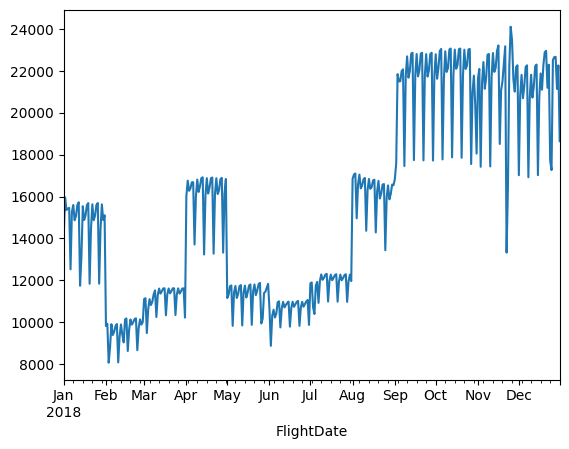

In [11]:
df_flights.FlightDate.value_counts().sort_index().plot()

In [13]:
df_flights.nunique().sort_values()

Year                                  1
Diverted                              2
Cancelled                             2
DepDel15                              2
ArrDel15                              2
                                   ... 
Distance                           1557
ArrDelay                           1561
Tail_Number                        6093
Flight_Number_Marketing_Airline    7151
Flight_Number_Operating_Airline    7173
Length: 61, dtype: int64

In [14]:
equal_cols = {col1: col2 for col1 in df_flights.columns for col2 in df_flights.columns if col1 != col2 and df_flights[col1].equals(df_flights[col2])}

In [15]:
equal_cols

{'Marketing_Airline_Network': 'IATA_Code_Marketing_Airline',
 'IATA_Code_Marketing_Airline': 'Marketing_Airline_Network',
 'Operating_Airline': 'IATA_Code_Operating_Airline',
 'IATA_Code_Operating_Airline': 'Operating_Airline'}

In [17]:
df_flights[["Marketing_Airline_Network", "IATA_Code_Marketing_Airline", "IATA_Code_Operating_Airline", "Operating_Airline"]]

,Marketing_Airline_Network,IATA_Code_Marketing_Airline,IATA_Code_Operating_Airline,Operating_Airline
0,DL,DL,9E,9E
1,DL,DL,9E,9E
2,DL,DL,9E,9E
3,DL,DL,9E,9E
4,DL,DL,9E,9E
...,...,...,...,...
637609,UA,UA,ZW,ZW
637610,UA,UA,ZW,ZW
637611,UA,UA,ZW,ZW
637612,UA,UA,ZW,ZW


In [5]:
cols_remove = ["DepTime", "DepDelayMinutes", "ArrTime", 
               "ArrDelayMinutes", "Year", "Quarter", "Month", "DayofMonth",
               "DayOfWeek", "Marketing_Airline_Network", "IATA_Code_Operating_Airline",
               "OriginAirportID", "DestAirportID", "DepartureDelayGroups", "DepTimeBlk",
               "TaxiOut", "WheelsOff", "WheelsOn", "TaxiIn", "DepDel15", "ArrivalDelayGroups",
                "ArrTimeBlk","DistanceGroup", ""]

In [6]:
df_flights = df_flights[df_flights.columns[~df_flights.columns.isin(cols_remove)]]
df_flights.shape

(5689512, 38)

In [23]:
for col in df_flights.columns:

    print(f"\n\n{col}")
    display(df_flights[col].value_counts(normalize=True))



FlightDate


FlightDate
2018-11-25    0.004238
2018-11-26    0.004123
2018-11-16    0.004081
2018-11-21    0.004074
2018-10-12    0.004055
                ...   
2018-02-04    0.001547
2018-02-24    0.001522
2018-02-17    0.001515
2018-02-10    0.001419
2018-02-03    0.001417
Name: proportion, Length: 365, dtype: float64



Airline


Airline
Southwest Airlines Co.                       0.237727
United Air Lines Inc.                        0.109248
SkyWest Airlines Inc.                        0.093469
Delta Air Lines Inc.                         0.081152
American Airlines Inc.                       0.067701
JetBlue Airways                              0.053609
Republic Airlines                            0.035773
Alaska Airlines Inc.                         0.032472
Spirit Air Lines                             0.030965
ExpressJet Airlines Inc.                     0.029384
Mesa Airlines Inc.                           0.027014
Envoy Air                                    0.022454
Frontier Airlines Inc.                       0.021098
Endeavor Air Inc.                            0.021097
Comair Inc.                                  0.020587
Air Wisconsin Airlines Corp                  0.017359
Allegiant Air                                0.016912
Horizon Air                                  0.014983
Hawaiian Airlines In



Origin


...

ArrDelay
-10.0      2.979852e-02
-9.0       2.960449e-02
-11.0      2.945878e-02
-8.0       2.938038e-02
-12.0      2.889225e-02
               ...     
-88.0      1.789991e-07
 1251.0    1.789991e-07
 1302.0    1.789991e-07
 1467.0    1.789991e-07
 1394.0    1.789991e-07
Name: proportion, Length: 1561, dtype: float64



ArrDel15


ArrDel15
0.0    0.805188
1.0    0.194812
Name: proportion, dtype: float64



DivAirportLandings


DivAirportLandings
0.0    0.997425
1.0    0.002436
9.0    0.000122
2.0    0.000016
Name: proportion, dtype: float64

In [ ]:
cols_remove = ["DOT_ID_Marketing_Airline", # same as iata but will other format "IATA_Code_Marketing_Airline"
                "DOT_ID_Operating_Airline", # same as airline code "Operating_Airline"
               "OriginCityMarketID", # already got city name "OriginCityName"
                "OriginStateFips", # already got state name "OriginState"
                "OriginWac" ,  #"OriginStateName"
                "DestCityMarketID", # already got city dest name "DestCityName"
                "DestStateFips", #"DestState"
                "DestWac",  # DestState
]

In [8]:
df_flights.groupby("DOT_ID_Marketing_Airline")["IATA_Code_Marketing_Airline"].nunique().value_counts()

IATA_Code_Marketing_Airline
1    11
Name: count, dtype: int64

In [12]:
df_flights.groupby("IATA_Code_Marketing_Airline")["DOT_ID_Marketing_Airline"].nunique().value_counts()

DOT_ID_Marketing_Airline
1    11
Name: count, dtype: int64

In [9]:
df_flights.groupby("DOT_ID_Operating_Airline")["Operating_Airline"].nunique().value_counts()

Operating_Airline
1    28
Name: count, dtype: int64

In [13]:
df_flights.groupby("Operating_Airline")["DOT_ID_Operating_Airline"].nunique().value_counts()

DOT_ID_Operating_Airline
1    28
Name: count, dtype: int64

In [10]:
df_flights.groupby("OriginCityMarketID")["OriginCityName"].nunique().value_counts()

OriginCityName
1    336
2      6
3      2
5      2
Name: count, dtype: int64

In [11]:
df_flights.groupby("OriginState")["OriginStateFips"].nunique().value_counts()

OriginStateFips
1    52
Name: count, dtype: int64

In [14]:
df_flights.groupby("OriginStateFips")["OriginState"].nunique().value_counts()

OriginState
1    52
Name: count, dtype: int64

In [15]:
df_flights.groupby("OriginWac")["OriginStateName"].nunique().value_counts()

OriginStateName
1    52
Name: count, dtype: int64

In [16]:
df_flights.groupby("OriginStateName")["OriginWac"].nunique().value_counts()

OriginWac
1    52
Name: count, dtype: int64

In [17]:
df_flights.groupby("DestCityMarketID")["DestCityName"].nunique().value_counts()

DestCityName
1    336
2      6
3      2
5      2
Name: count, dtype: int64

In [18]:
df_flights.groupby("DestCityName")["DestCityMarketID"].nunique().value_counts()

DestCityMarketID
1    364
Name: count, dtype: int64

In [19]:
df_flights.groupby("DestStateFips")["DestState"].nunique().value_counts()

DestState
1    52
Name: count, dtype: int64

In [20]:
df_flights.groupby("DestState")["DestStateFips"].nunique().value_counts()

DestStateFips
1    52
Name: count, dtype: int64

In [21]:
df_flights.groupby("DestState")["DestWac"].nunique().value_counts()

DestWac
1    52
Name: count, dtype: int64

In [22]:
df_flights.groupby("DestWac")["DestState"].nunique().value_counts()

DestState
1    52
Name: count, dtype: int64

In [23]:
df_flights = df_flights[df_flights.columns[~df_flights.columns.isin(cols_remove)]]
df_flights.shape

(5689512, 38)

In [24]:
list_cols_keep = df_flights.columns
list_cols_keep

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepDelay', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance',
       'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
       'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline',
       'Operating_Airline', 'DOT_ID_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginAirportSeqID',
       'OriginCityMarketID', 'OriginCityName', 'OriginState',
       'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportSeqID',
       'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips',
       'DestStateName', 'DestWac', 'CRSArrTime', 'ArrDelay', 'ArrDel15',
       'DivAirportLandings'],
      dtype='object')

# 3. Processing

In [3]:
list_cols_keep = ['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepDelay', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance',
       'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
       'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline',
       'Operating_Airline', 'DOT_ID_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginAirportSeqID',
       'OriginCityMarketID', 'OriginCityName', 'OriginState',
       'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportSeqID',
       'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips',
       'DestStateName', 'DestWac', 'CRSArrTime', 'ArrDelay', 'ArrDel15',
       'DivAirportLandings']

In [4]:
path = "../../data/Combined_Flights_2018.parquet"

df_flights = pl.read_parquet(
    path,
    columns=list_cols_keep)

In [5]:
df_flights.shape

(5689512, 38)